# Neuropixels 2.0 to NWB Conversion

This notebook demonstrates the conversion of an IBL session recorded with **Neuropixels 2.0 (NP2.4) probes** to the NWB format. The session (subject KM_038, 2025-05-19) was recorded at the Steinmetz Lab (University of Washington) using 3 NP2.4 probes, each with 4 shanks, for a total of 12 independent shank recordings.

## What is different from the Brainwide Map (BWM) conversion?

The only structural difference is the raw ephys data. NP2.4 probes have **4 physically separated shanks per probe**, unlike the single-shank Neuropixels 1.0 used in the BWM.

Everything else (trials, wheel, licks, pose estimation, passive task, motion energy) follows the standard IBL ALF format and is identical to BWM sessions. Once this session is registered on openalyx, the processed data conversion will use the same `convert_session()` pipeline as BWM.

## Ad-hoc per-shank file format and its implications

For the standard Neuropixels 1.0 flow, raw ephys conversion follows a well-tested pipeline: SpikeGLX files are read through SpikeInterface's Neo-based readers, which feed into NeuroConv's recording interfaces. This path has been validated across hundreds of BWM sessions and benefits from the robustness of the SpikeInterface/Neo/NeuroConv ecosystem.

The NP2 session in this notebook uses a **different approach**. The original recording team split and compressed the SpikeGLX data on a per-shank basis, creating separate `.cbin`/`.meta` files per shank (`probe00a/`, `probe00b/`, etc.). Standard SpikeGLX recordings store all shanks in a single file per probe. Additionally, the `.meta` files were modified to reflect the per-shank channel subsets: each shank's `.meta` file shares the same `imec` index as the physical probe but describes only 97 channels (96 electrodes + 1 sync) rather than the full probe complement. Fields like `snsGeomMap`, `imroTbl`, and `snsChanMap` were adjusted accordingly.

Because of these modifications to both the file organization and the metadata format, the standard SpikeGLX readers (Neo, SpikeInterface) cannot parse this data directly. We built a dedicated `IblNeuropixels2Converter` with custom extractor and interface classes (`IblNeuropixels2ShankExtractor`, `IblNeuropixels2ShankInterface`) that handle the per-shank decompression, metadata parsing, and probe geometry extraction. **This converter is less robust than the standard pipeline** because it relies on project-specific loading logic rather than the well-maintained SpikeInterface/Neo path. If future NP2 sessions from other labs follow the standard SpikeGLX file layout (all shanks in a single file), they would use the regular pipeline instead.

For detailed technical documentation of the data format and the components that were built, see the [neuropixels_2 documentation](https://github.com/h-mayorquin/IBL-to-nwb/tree/main/documentation/neuropixels_2) in the repository.

## Local-file based conversion

While the data is available on the internal alyx server, the raw conversion works from **pre-downloaded local files**, not directly from alyx. This is because preprocessing steps are required before the data can be written to NWB: the per-shank `.cbin` files must be decompressed to `.bin` format, and the shank folder structure must be discovered and mapped to probe/shank indices. These steps happen on local disk before the NWB writing begins.

## Current caveats

- **Data not yet on openalyx.** The session data was shared directly by the experimenters and is only available on the internal alyx server. Our standard conversion interfaces rely on the ONE API, which queries openalyx. For now, we use a standalone script (`convert_neuropixels2_to_nwb.py`) for the raw ephys conversion. A temporary workaround script (`convert_neuropixels2_to_nwb_full.py`) handles the processed data by loading directly from local ALF files.
- **No anatomical localization.** Histology has not been processed for this session, so electrode coordinates are probe-relative only (no Allen CCF brain region assignments).
- **No spike sorting in the NWB yet.** The sorted spike data (units) exists in the source ALF files but has not been added to the NWB file in this demo. Once on openalyx, `IblSortingInterface` will handle this automatically.

## Raw NWB: Multi-shank electrode geometry

The raw NWB file contains 24 electrical series (12 shanks x 2 bands: AP at 30 kHz and LF at 2.5 kHz), plus NIDQ sync signals. Each shank has its own electrode group with 96 active channels and probe-relative geometry.

In [1]:
# NOTE: These paths point to locally converted NWB files on the developer's machine.
# To reproduce, run convert_neuropixels2_to_nwb.py with your own paths after
# downloading the session data from the internal alyx server.
from pathlib import Path 
from pynwb import read_nwb 

nwbfile_path = Path("/media/heberto/Expansion/ibl_conversion/nwbfiles/stub/sub-KM-038/sub-KM-038_ses-0fc48eb3-0a80-4287-95f6-892a00c3cac1_desc-raw_ecephys.nwb")
assert nwbfile_path.exists()

nwbfile_raw = read_nwb(nwbfile_path)
nwbfile_raw

Data type,int16
Shape,"(100, 97)"
Array size,18.95 KiB
Chunk shape,"(100, 64)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),19400
Compressed size (bytes),12358
Compression ratio,1.5698333063602525
Data type,float64
Shape,"(100,)"


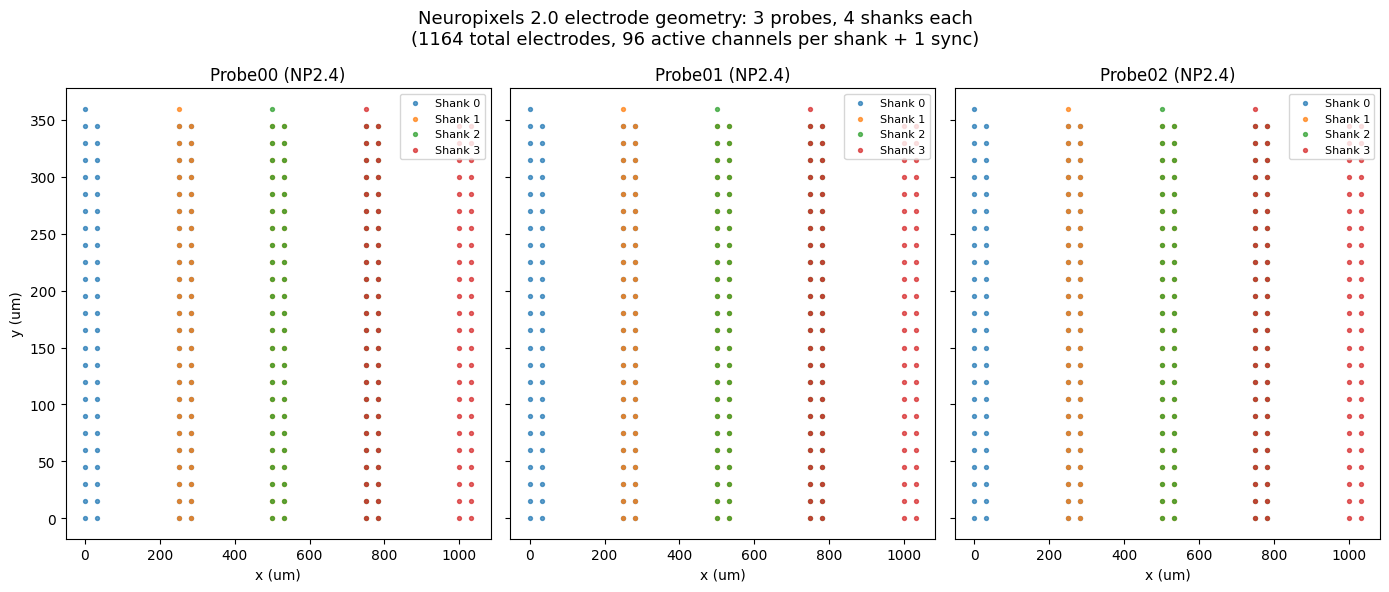

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

electrodes_df = nwbfile_raw.electrodes.to_dataframe()

# NP2.4 shanks are separated by 250 um. The rel_x/rel_y in the NWB file are
# local to each shank, so we add a global x offset based on the shank index
# to reveal the 4-shank structure.
shank_spacing_um = 250

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

for probe_index, probe_name in enumerate(["Probe00", "Probe01", "Probe02"]):
    ax = axes[probe_index]
    probe_groups = sorted(
        [gn for gn in electrodes_df["group_name"].unique() if gn.startswith(probe_name)]
    )

    for group_name in probe_groups:
        shank_index = int(group_name[-1])
        mask = electrodes_df["group_name"] == group_name
        sub = electrodes_df[mask]

        # Offset x by shank index to show the physical separation
        global_x = sub["rel_x"] + shank_index * shank_spacing_um

        ax.scatter(global_x, sub["rel_y"], s=8, alpha=0.7, label=f"Shank {shank_index}")

    ax.set_title(f"{probe_name} (NP2.4)", fontsize=12)
    ax.set_xlabel("x (um)")
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("y (um)")
fig.suptitle(
    "Neuropixels 2.0 electrode geometry: 3 probes, 4 shanks each\n"
    f"({len(electrodes_df)} total electrodes, 96 active channels per shank + 1 sync)",
    fontsize=13,
)
fig.tight_layout()
plt.show()


The figure above shows the electrode layout for all 3 probes. Each subplot displays 4 shanks (color-coded), with x positions offset by 250 um to reflect the physical shank separation on the NP2.4 probe. Within each shank, the dual-column contact layout is visible: two columns of electrodes separated by 32 um, which is the standard NP2 contact arrangement. Each shank has 96 active recording channels plus 1 sync channel (the isolated dot at the bottom of Shank 0), for a total of 1164 electrodes across the entire session.

Note that in the NWB file, the `rel_x` and `rel_y` coordinates are stored relative to each shank (not global), so the inter-shank offset shown here is applied for visualization only. The electrode group assignment (`Probe00Shank0`, `Probe00Shank1`, etc.) is what distinguishes channels from different shanks.

## Processed NWB: Behavioral data

The processed NWB contains the same behavioral data types as a standard BWM session: trials (with 19 columns), wheel position and movements, lick times, pose estimation from 3 cameras (Lightning Pose), ROI motion energy, and passive task epochs (spontaneous activity, receptive field mapping, task replay with gabor stimuli).

None of this data is NP2-specific. It follows the standard IBL ALF format and will be converted through `convert_session()` once the session is on openalyx.

In [3]:
# Processed NWB generated locally using convert_neuropixels2_to_nwb_full.py
from pathlib import Path 
from pynwb import read_nwb 

nwbfile_path = Path("/media/heberto/Expansion/ibl_conversion/nwbfiles/stub/sub-KM-038/sub-KM-038_ses-0fc48eb3-0a80-4287-95f6-892a00c3cac1_desc-processed_behavior.nwb")
assert nwbfile_path.exists()

nwbfile_processed = read_nwb(nwbfile_path)  
nwbfile_processed

Data type,float64
Shape,"(18259,)"
Array size,142.65 KiB
Chunk shape,"(18259,)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),146072
Compressed size (bytes),243
Compression ratio,601.119341563786
Data type,float64
Shape,"(18259,)"
